In [1]:
import SOAP
from SOAP import PHOENIX
import matplotlib.pyplot as plt
import numpy as np
from ldtk import LDPSetCreator, BoxcarFilter


In [ ]:
# Stellar properties
diffrotB=0.163                                      # Linear differential rotation coeff
diffrotC=0.121                                      # Quadratic differential rotation coeff
logg= 4.4                                           # Logarithm of surface gravity [cm/s^2]
logg_sig=0.001                                      # Uncertainty in logg [cm/s^2]
feh= 0.00                                           # Metallicity in dex
feh_sig= 0.01                                       # Uncertainty in feh
Teff=5778                                           # Stellar effective temperature [K]
Teff_sig=10                                         # Uncertainty in Teff [K]
mass=1.0                                            # Stellar mass [Msun]
radius=1.0                                          # Stellar radius [Rsun]
prot=25.67                                          # Stellar rotation period [days]

In [3]:
# Define the wavelength range for the model spectrum
λ = (3800, 7880)
# Load the PHOENIX model spectrum
input_spectrum = PHOENIX(wave_range=λ, teff=5778, logg=4.4374, Z=0);

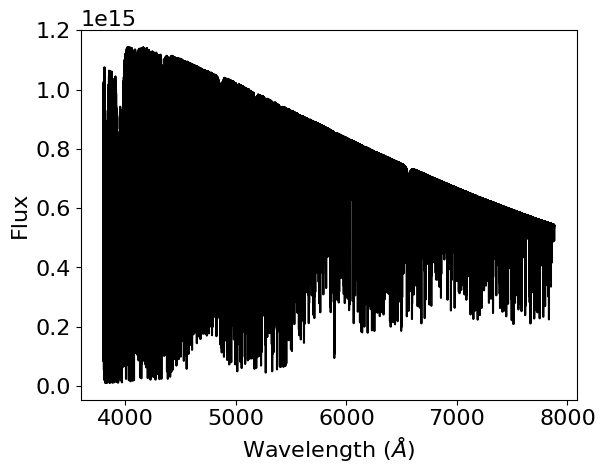

In [4]:
# Plot the model spectrum (local)
plt.plot(input_spectrum.wave,input_spectrum.flux,"k")
plt.xlabel("Wavelength ("+r"$\AA$"+")")
plt.ylabel("Flux");

In [5]:

# Downsample it to make computations faster (this can be adjusted as needed)
input_spectrum.flux=(input_spectrum.flux/np.max(input_spectrum.flux))[::3]
input_spectrum.wave=input_spectrum.wave[::3]

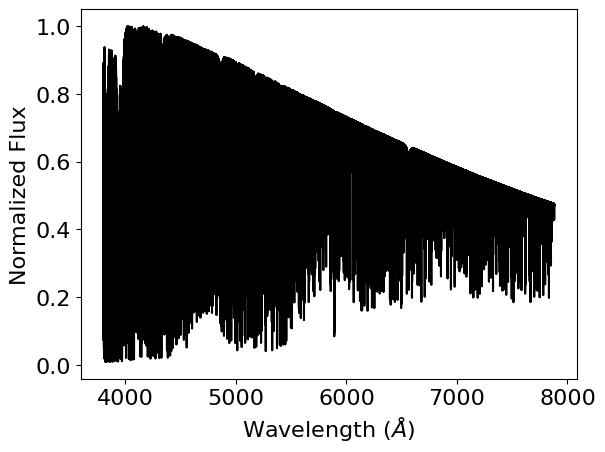

In [ ]:
# Plot thje downsampled model spectrum (local)
plt.plot(input_spectrum.wave,input_spectrum.flux,"k")
plt.xlabel("Wavelength ("+r"$\AA$"+")")
plt.ylabel("Normalized Flux");

In [ ]:
#Compute the limb darkening coefficients for the specified star parameters
filters = [BoxcarFilter('filter',λ[0]/10, λ[1]/10)]
sc = LDPSetCreator(teff=(Teff, Teff_sig),
logg=(logg,logg_sig),
z=(feh, feh_sig),
filters=filters)
ps = sc.create_profiles()      	         # Create the limb darkening profiles
ldcn, qe = ps.coeffs_qd(do_mc=True) #coeficientes e os seus erros de perfil quadrático

In [8]:
sim = SOAP.Simulation(pixel=input_spectrum,pixel_spot=None, inst_reso=140000, grid=300, active_regions=[], ring=None);

In [ ]:
#Disable the planet in the simulation
sim.planet.Rp=0

In [ ]:
# Set the stellar parameters
sim.star.set(prot=prot, u1=ldcn[0][0], u2=ldcn[0][1], start_psi=0,radius=radius,mass=mass,teff=Teff);

In [ ]:
# Calculate the RV signal, skipping BIS and FWHM calculations for speed
output=sim.calculate_signal(psi=[0], skip_bis=True, skip_fwhm=True, skip_rv=False)

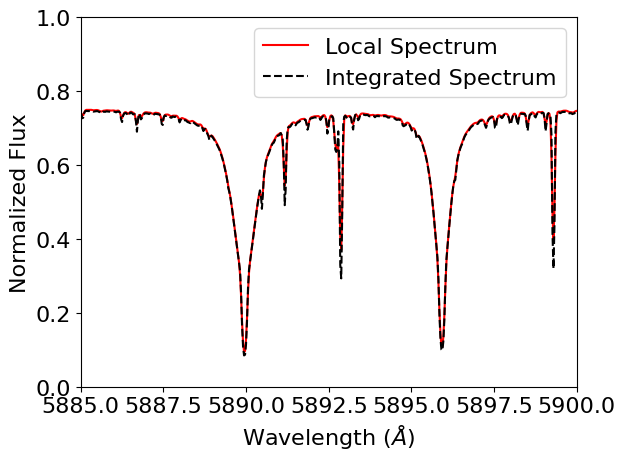

In [14]:
plt.plot(sim.pixel.wave, sim.integrated_spectra[0], 'r', label='Local Spectrum')
plt.plot(input_spectrum.wave, input_spectrum.flux, 'k--', label='Integrated Spectrum')
plt.xlim(5885, 5900)
plt.ylim(0,1)
plt.xlabel("Wavelength ("+r"$\AA$"+")")
plt.ylabel("Normalized Flux");
plt.legend()